In [14]:
import pandas as pd
import numpy as np
import skimpy as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
df = pd.read_csv('data/Student Depression Dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27896 non-null  object 
 2   Age                                    27893 non-null  float64
 3   City                                   27900 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27896 non-null  object 
 11  Di

In [4]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
df.isnull().sum()

id                                       0
Gender                                   5
Age                                      8
City                                     1
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           5
Dietary Habits                           0
Degree                                   4
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         3
Financial Stress                         3
Family History of Mental Illness         4
Depression                               0
dtype: int64

In [10]:
df_summary = sk.skim(df)
df_summary

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 27901  │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 18     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 4     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA %           ┃ mean      ┃ sd      ┃ p0 ┃ p25   ┃ p50   ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ id             │  0 │              0 │     70440 │   40640 │  2 │ 35040 │ 70680 │ 105800 │ 140700 │ ▇▇▇▇▇▇ │  │
│ │ Age            │  8 │ 0.028672807426 │     25.82 │   4.906 │ 18 │    21 │    25 │     30 │     59 │  ▇▇▃   │  │
│ │                │    │         257125 │           │         │    │       │       │        │        │        │  │
│ │ Academic       │  0 │              0 │     3.141 │   1.381 │  0 │     2 │     3 │      4 │      5 │  ▅▅▇▆▇ │  │
│ │ Pressure       │    │                │           │         │    │       │       │        │        │        │  │
│ │ Work Pressure  │  0 │              0 │ 0.0004301 │ 0.04399 │  0 │     0 │     0 │      0 │      5 │   ▇    │  │
│ │ CGPA           │  0 │              0 │     7.656 │   1.471 │  0 │  6.29 │  7.77 │   8.92 │     10 │    ▆▇▇ │  │
│ │ Study          │  0 │              0 │     2.944 │   1.361 │  0 │     2 │     3 │      4 │      5 │  ▇▇▇▇▆ │  │
│ │ Satisfaction   │    │                │           │         │    │       │       │        │        │        │  │
│ │ Job            │  0 │              0 │  0.000681 │ 0.04439 │  0 │     0 │     0 │      0 │      4 │   ▇    │  │
│ │ Satisfaction   │    │                │           │         │    │       │       │        │        │        │  │
│ │ Work/Study     │  3 │ 0.010752302784 │     7.157 │   3.708 │  0 │     4 │     8 │     10 │     12 │ ▂▂▂▃▃▇ │  │
│ │ Hours          │    │          84642 │           │         │    │       │       │        │        │        │  │
│ │ Financial      │  3 │ 0.010752302784 │      3.14 │   1.437 │  1 │     2 │     3 │      4 │      5 │ ▆▆ ▆▇▇ │  │
│ │ Stress         │    │          84642 │           │         │    │       │       │        │        │        │  │
│ │ Depression     │  0 │              0 │    0.5855 │  0.4926 │  0 │     0 │     1 │      1 │      1 │ ▆    ▇ │  │
│ └────────────────┴────┴────────────────┴───────────┴─────────┴────┴───────┴───────┴────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃    ┃           ┃          ┃           ┃          ┃           ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min      ┃ max       ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━

In [15]:
df = df.drop(columns=['id', 'Profession'])

In [17]:
df.select_dtypes(include='number').columns

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress', 'Depression'],
      dtype='object')

In [18]:
for col in df.select_dtypes(include='number').columns:
    df[col]=df[col].fillna(df[col].median())

In [19]:
for col in df.select_dtypes(include=['category','object']).columns:
    df[col]=df[col].fillna(df[col].mode()[0])

In [23]:
X = df.drop('Depression', axis=1)
y = df['Depression']

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)                                  


In [31]:
# import label encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
#now apply the label encoder to the categorical columns in the training set
for col in X_train.select_dtypes(include=['category', 'object']).columns:
    X_train[col] = label_encoder.fit_transform(X_train[col])
#and now to the test set
for col in X_test.select_dtypes(include=['category', 'object']).columns:
    X_test[col] = label_encoder.transform(X_test[col])


ValueError: y contains previously unseen labels: 'Female'

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27896 non-null  object 
 2   Age                                    27893 non-null  float64
 3   City                                   27900 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         278

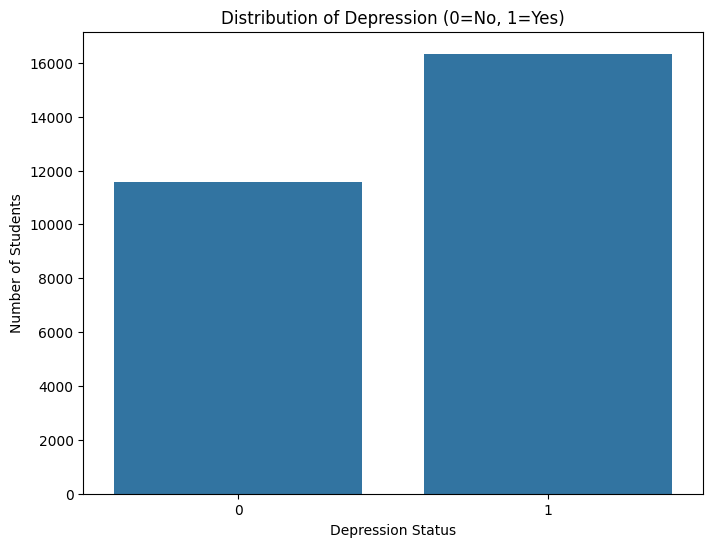

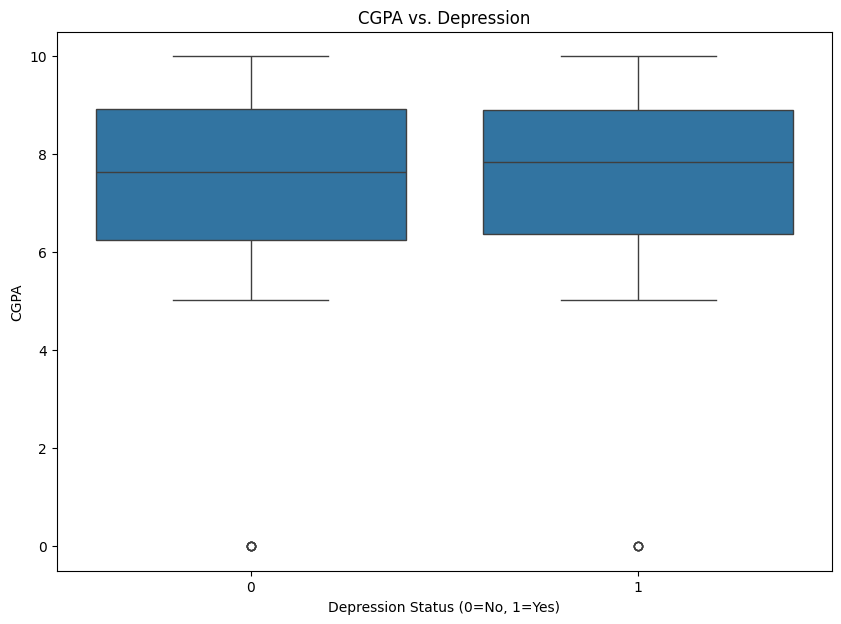

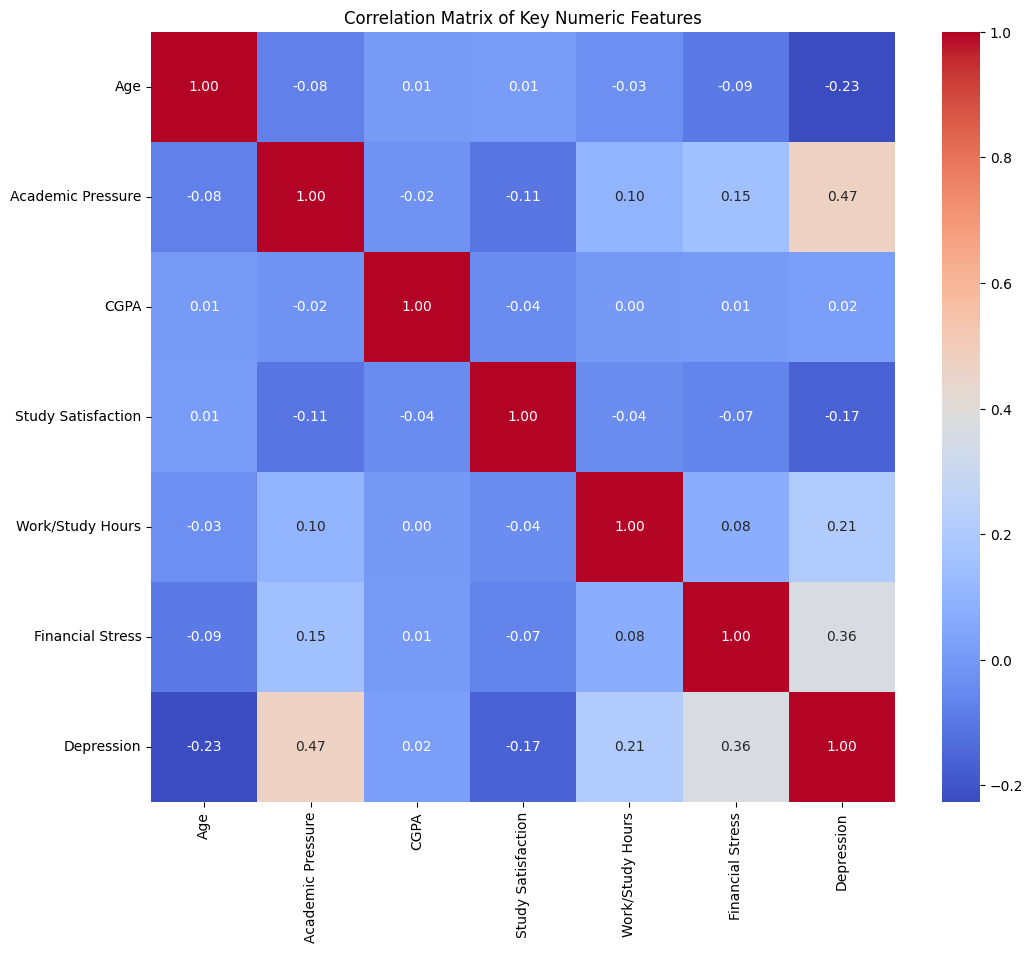

Data has been split!
Training set size: 19530 samples
Testing set size: 8371 samples

Training the Logistic Regression model...

Model training is complete! We now have a trained model ready for testing.

Our model's accuracy on the test data is: 0.8469

Here's a detailed report on how our model performed:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      3470
           1       0.86      0.89      0.87      4901

    accuracy                           0.85      8371
   macro avg       0.84      0.84      0.84      8371
weighted avg       0.85      0.85      0.85      8371



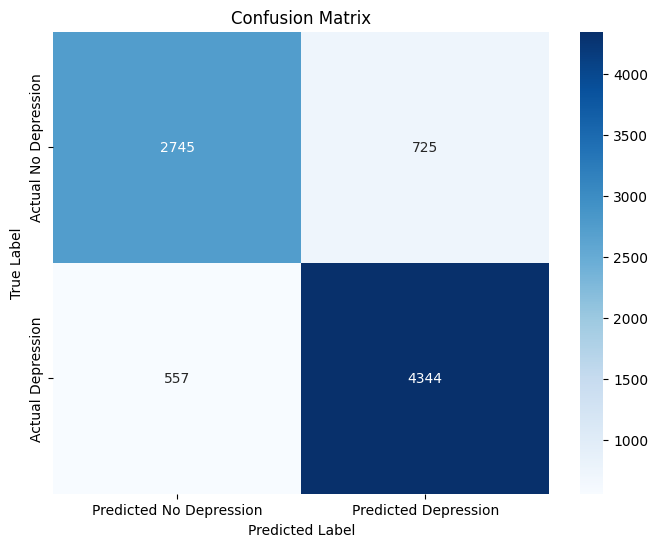

In [ ]:



# We'll drop columns that don't seem useful for our prediction.
# 'id' is just an identifier, and 'Profession' has almost all 'Student' values.


# Our 'Depression' column is what we want to predict, so we'll separate it.
# X will be our features (the columns we use to predict).
# y will be our target (the column we are trying to predict).


# Next, we need to handle the missing values. We'll use a simple method:
# For numbers, we'll fill in missing spots with the median (the middle value).
# For text, we'll use the mode (the most frequent value).

# We find our numeric columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_features:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)

# And our categorical (text) columns
categorical_features = X.select_dtypes(include=['object']).columns
for col in categorical_features:
    mode_val = X[col].mode()[0]
    X[col] = X[col].fillna(mode_val)

print("\nMissing values have been filled!")

# Now we need to convert text data into numbers and put all numeric data on the same scale.
# We'll use a `ColumnTransformer` to handle both steps at once.
preprocessor = ColumnTransformer(
    transformers=[
        # StandardScaler will normalize our numeric columns (make them have a mean of 0).
        ('num', StandardScaler(), numerical_features),
        # OneHotEncoder will convert our text columns into numbers our model can use.
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# We apply this preprocessor to our data.
X_processed = preprocessor.fit_transform(X)

print("\nData has been preprocessed!")
print(f"The new shape of our data is: {X_processed.shape}")

# ==============================================================================
# Step 3: Exploratory Data Analysis (EDA)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Let's look at the distribution of our target variable, 'Depression'.
# This helps us see if the dataset is balanced.
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribution of Depression (0=No, 1=Yes)')
plt.xlabel('Depression Status')
plt.ylabel('Number of Students')
plt.show()

# We can also check for relationships between features and the target.
# A boxplot is great for comparing a numeric feature with a categorical one.
# Here we compare CGPA with depression status.
plt.figure(figsize=(10, 7))
sns.boxplot(x=df['Depression'], y=df['CGPA'])
plt.title('CGPA vs. Depression')
plt.xlabel('Depression Status (0=No, 1=Yes)')
plt.ylabel('CGPA')
plt.show()

# A correlation heatmap shows us which numeric features are related to each other.
numeric_cols_for_corr = ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']
correlation_matrix = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Numeric Features')
plt.show()

# ==============================================================================
# Step 4: Building and Training the Model
# ==============================================================================
from sklearn.linear_model import LogisticRegression

# We need to split our data into a training set and a testing set.
# We'll use 70% of the data to train the model and 30% to test its performance.
# `stratify=y` makes sure both sets have a similar mix of students with and without depression.
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

print("Data has been split!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# We create an instance of our Logistic Regression model.
# `max_iter=1000` just gives the model enough iterations to find a good solution.
model = LogisticRegression(max_iter=1000)

# This is where the magic happens! We train our model using the training data.
print("\nTraining the Logistic Regression model...")
model.fit(X_train, y_train)

print("\nModel training is complete! We now have a trained model ready for testing.")

# ==============================================================================
# Step 5: Evaluating the Model
# ==============================================================================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Now we'll use our trained model to make predictions on the test data.
# The model has never seen this data before, so this is a true test of its performance.
y_pred = model.predict(X_test)

# The accuracy score tells us the percentage of correct predictions.
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOur model's accuracy on the test data is: {accuracy:.4f}")

# The classification report gives us more detail, including precision and recall for each category.
print("\nHere's a detailed report on how our model performed:")
print(classification_report(y_test, y_pred))

# A confusion matrix is a great visual tool to see where the model made its mistakes.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Depression', 'Predicted Depression'],
            yticklabels=['Actual No Depression', 'Actual Depression'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()